# CE888-7-SP : Data Science Project

In [1]:
# load the train validation and test data set
import pandas as pd

# Load train_filled set from CSV file
train_filled = pd.read_csv('train_filled.csv')

# Load validation set from CSV file
validation = pd.read_csv('validation.csv')

# Load test set from CSV file
test = pd.read_csv('test.csv')

In [2]:
train_filled.head(2)

,Unnamed: 0,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,month,year
0,2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0,1,2010
1,2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0,1,2010


after looking at my data i can notice that there is some issue i have to fix first i have to rename my index with datetime and set it as my index

In [3]:
# Set the 'Unnamed' column as the index
train_filled.set_index('Unnamed: 0', inplace=True)
# Rename the index to 'datetime'
train_filled = train_filled.rename_axis('datetime')
# Print the DataFrame to verify the change
train_filled.head(2)

,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,month,year
datetime,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0,1,2010
2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0,1,2010


In [4]:
# there are two columns year and month i have to drop because i should not have them and maby by mistake they were created in the privous data exploration
train_filled = train_filled.drop(columns=['year', 'month'], errors='ignore')
train_filled.head(2)

,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
datetime,,,,,,,,,,,,,,
2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0
2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0


In [5]:
# doing the same thing to my validation set
# Set the 'datetime' column as the index
validation.set_index('datetime', inplace=True)
validation = validation.drop(columns=['year'], errors='ignore')
validation.head(2)


,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
datetime,,,,,,,,,,,,,,,
2019-01-01 00:00:00,8.4,5.3,81.30,0.0,0.0,NaN,0.0,0.0,9.4,292.0,1035.2,100.0,0.0,0.0,0.0
2019-01-01 01:00:00,8.4,5.0,79.38,0.0,0.0,NaN,0.0,0.0,13.3,292.0,1034.8,100.0,0.0,0.0,0.0


In [6]:
# looking at my test set to see how is it look like
test.head(2)

,datetime,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,year
0,2022-01-01 00:00:00,12.0,11.6,97.51,0.015,100.0,rain,0.0,0.0,14.4,193.0,1021.6,99.2,0.0,0.0,0.0,2022
1,2022-01-01 01:00:00,12.2,11.7,96.90,0.000,0.0,NaN,0.0,0.0,16.8,209.0,1021.3,100.0,0.0,0.0,0.0,2022


In [7]:
test.set_index('datetime', inplace=True)
test = test.drop(columns=['year'], errors='ignore')
test.head(2)


,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
datetime,,,,,,,,,,,,,,,
2022-01-01 00:00:00,12.0,11.6,97.51,0.015,100.0,rain,0.0,0.0,14.4,193.0,1021.6,99.2,0.0,0.0,0.0
2022-01-01 01:00:00,12.2,11.7,96.90,0.000,0.0,NaN,0.0,0.0,16.8,209.0,1021.3,100.0,0.0,0.0,0.0


# baseline and machine learning 'huber' modelling


###### The final goal is to predict 24 hour in advance the surplus energy.

i will divide my data set to a train set 'First 9 years (2010-2018)' and for avoid overfitting i will use Next 3 years (2019-2021) for validation to compare different model two model and the remaining for test set


In [8]:
# i will do all the prives steps that was done to the train set to the validation set
# Step 1: Detect missing values and Count missing values in each column
missing_values = validation.isnull().sum()  
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 temp                   46
dew                    60
humidity               57
precip                 59
precipprob             59
preciptype          24442
snow                 7733
snowdepth            7732
windspeed              63
winddir                55
sealevelpressure      175
cloudcover             59
solarradiation         64
solarenergy            51
uvindex                69
dtype: int64


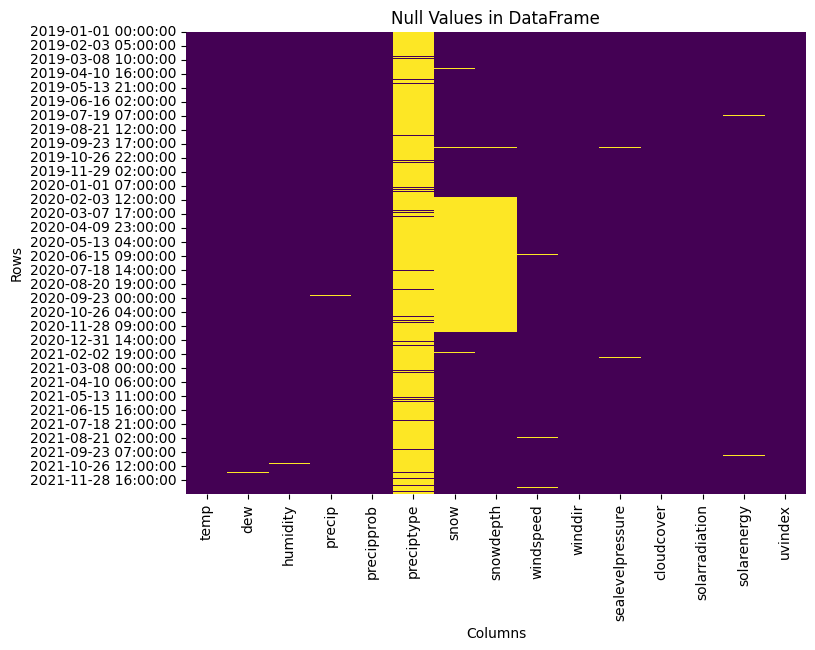

In [9]:
# Plotting null values
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(validation.isnull(), cmap='viridis', cbar=False)
plt.title('Null Values in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [10]:
# dealing with missing values 
# i will delete perciptype because most of its vlaues missing and i do not think it is important
validation.drop(columns=['preciptype'], inplace=True)

# Display the modified training set
print(validation.shape)

(26281, 14)


In [11]:
# detect the duplicated and keep the first one 
validation[validation.index.duplicated(keep=False)].head(20)
validation = validation[~validation.index.duplicated(keep='first')]
len(validation)

26278

that is mean that there is duplicated dates because after removing the duplucation the numbert of the rows reduces after that i will fill the missing dates


In [12]:
import pandas as pd
# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=validation.index.min(), end=validation.index.max(), freq='h')
# Ensure full_hourly_range and validation.index are datetime objects
full_hourly_range = pd.to_datetime(full_hourly_range)
validation.index = pd.to_datetime(validation.index)
# Find missing hours by comparing the full hourly range with the existing hours in the index
missing_hours = full_hourly_range[~full_hourly_range.isin(validation.index)]
# Calculate the number of missing hours
num_missing_hours = len(missing_hours)
# Use isin method
missing_hours = full_hourly_range[~full_hourly_range.isin(validation.index)]
# Print the number of missing hours
print("Number of missing hours which means rows also in validation is:", num_missing_hours)

Number of missing hours which means rows also in validation is: 3


In [13]:
# Create a date range from the first date to the last date in the index
full_date_range = pd.date_range(start=validation.index.min(), end=validation.index.max(), freq='h')
# Find missing dates by comparing the full date range with the existing dates in the index
missing_dates = full_date_range[~full_date_range.isin(validation.index)]
# Print the missing dates
print("Missing dates:")
print(missing_dates)

Missing dates:
DatetimeIndex(['2019-03-31 01:00:00', '2020-03-29 01:00:00',
               '2021-03-28 01:00:00'],
              dtype='datetime64[ns]', freq=None)


In [14]:
#i willfillthe missing rows in validation set
# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=validation.index.min(), end=validation.index.max(), freq='h')
# Reindex the DataFrame to include all the rows in the full date range
validation_filled_1 = validation.reindex(full_hourly_range)
# Interpolate missing values linearly
validation_filled_1 = validation_filled_1.interpolate(method='linear')
# Print the shape of the DataFrame without removing the index name
print(validation_filled_1.shape)  # Note: This will not remove the index name

(26281, 14)


In [15]:
# i will Fill missing or NaN values using linear interpolation
validation_filled = validation_filled_1.interpolate(method='linear')
# Display the DataFrame after filling missing values
print(validation_filled.shape)

(26281, 14)


In [16]:
# second i will do all the steps to test set
# Step 1: Detect missing values and Count missing values in each column
missing_values = test.isnull().sum()  
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 temp                   37
dew                    38
humidity               39
precip                 56
precipprob             42
preciptype          13673
snow                  140
snowdepth             674
windspeed              39
winddir                47
sealevelpressure       38
cloudcover             43
solarradiation        106
solarenergy           119
uvindex               114
dtype: int64


In [17]:
# dealing with missing values 
# i will delete perciptype because most of its vlaues missing and i do not think it is important
test.drop(columns=['preciptype'], inplace=True)
# Display the modified training set
print(test.shape)

(17652, 14)


In [18]:
# detect the duplicated and keep the first one 
test[test.index.duplicated(keep=False)].head(20)
test = test[~test.index.duplicated(keep='first')]
len(test)

17650

In [19]:
import pandas as pd
# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=test.index.min(), end=test.index.max(), freq='h')
# Ensure full_hourly_range and validation.index are datetime objects
full_hourly_range = pd.to_datetime(full_hourly_range)
test.index = pd.to_datetime(test.index)
# Find missing hours by comparing the full hourly range with the existing hours in the index
missing_hours = full_hourly_range[~full_hourly_range.isin(test.index)]
# Calculate the number of missing hours
num_missing_hours = len(missing_hours)
# Use isin method
missing_hours = full_hourly_range[~full_hourly_range.isin(test.index)]
# Print the number of missing hours
print("Number of missing hours which means rows also in test is:", num_missing_hours)

Number of missing hours which means rows also in test is: 2


In [20]:
#i will fill the missing rows in test set
import pandas as pd
# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=test.index.min(), end=test.index.max(), freq='h')
# Reindex the DataFrame to include all the rows in the full date range
test_filled_1 = test.reindex(full_hourly_range)
# Interpolate missing values linearly
test_filled_1 = test_filled_1.interpolate(method='linear')
# Print the shape of the DataFrame without removing the index name
print(test_filled_1.shape)  # Note: This will not remove the index name

(17652, 14)


In [21]:
# Fill missing or NaN values using linear interpolation
test_filled = test_filled_1.interpolate(method='linear')
# Display the DataFrame after filling missing values
print(test_filled.shape)

(17652, 14)


# baseline modelling

In [22]:
# creating a function for masure predicted error
def measure_forecast_error(label, forecast):
    '''We will use this function to measure the performance of our baseline models'''
    print('MAE = %.2f ' % mean_absolute_error(label, forecast))
    print('MAPE = %.2f%%' % (100*mean_absolute_percentage_error(label, forecast)))
    print('R2 = %.2f' % r2_score(label, forecast))

In [23]:
# creating a function to return mean abslote percentage error
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

MAE = 71.20 
MAPE = inf%
R2 = 0.49


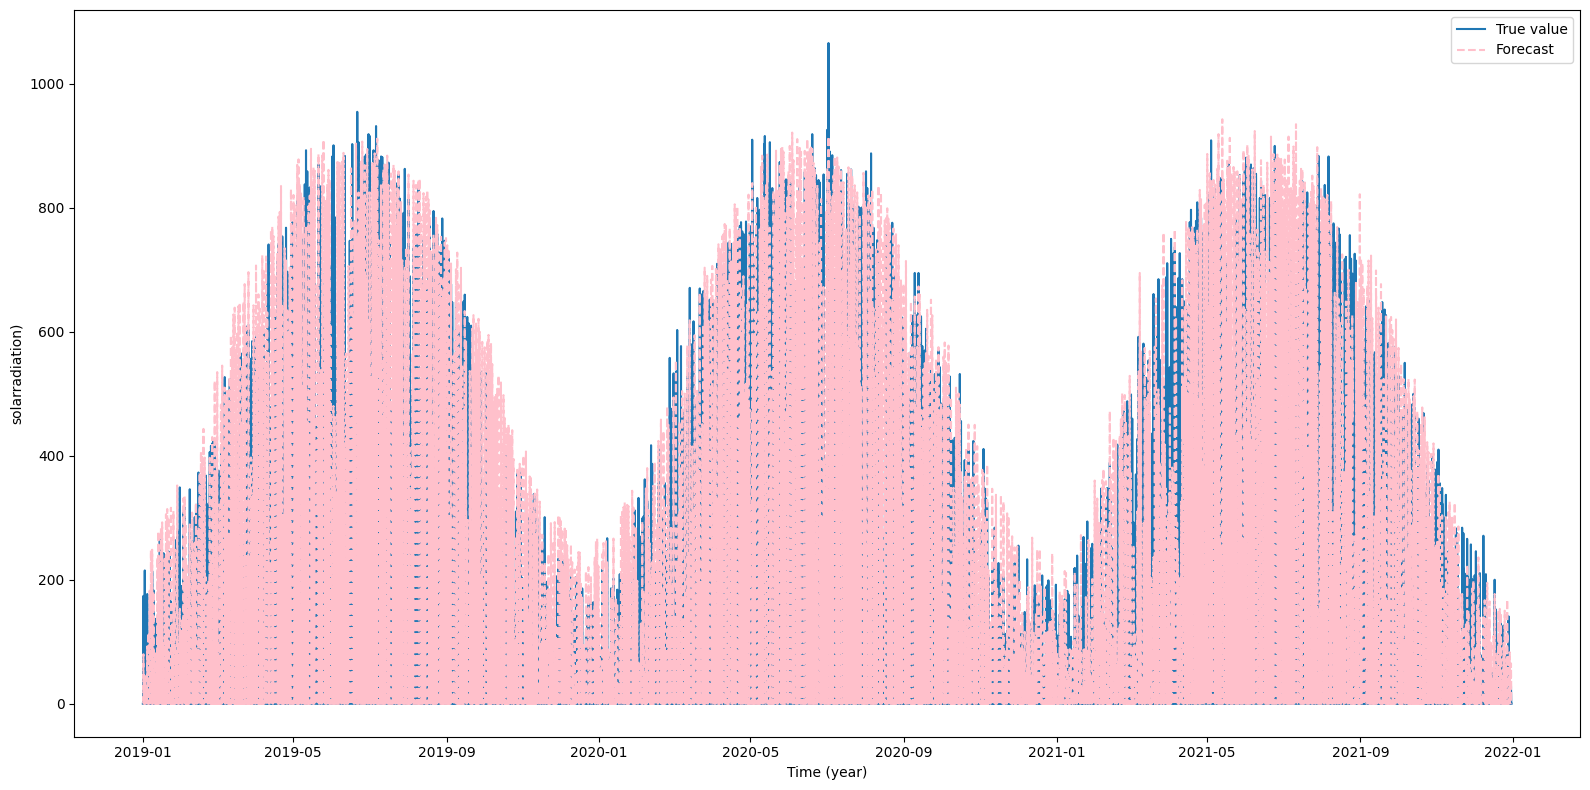

In [24]:
# using baseline model on just validation set i took the last for year of the training set to make my prediction and calculate the mae rather than the mean 
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import r2_score
# taking the last four year and implement tge function to calculate the mae
validation_filled['baseline_last_period'] = train_filled.loc['2016-01-01':'2018-12-31 00:00:00']['solarradiation'].values
measure_forecast_error(validation_filled['solarradiation'], validation_filled['baseline_last_period'])
#ploting
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(validation_filled.index, validation_filled['solarradiation'], label='True value')
ax.plot(validation_filled.index, validation_filled['baseline_last_period'], '--', color='pink', label='Forecast')

ax.set_xlabel('Time (year)')
ax.set_ylabel('solarradiation)')

plt.legend(loc='best')
plt.tight_layout()
plt.savefig('./baseline_periodicity.pdf', dpi=1000)

MAE = 9.40 
MAPE = 8857.57%
R2 = -0.74


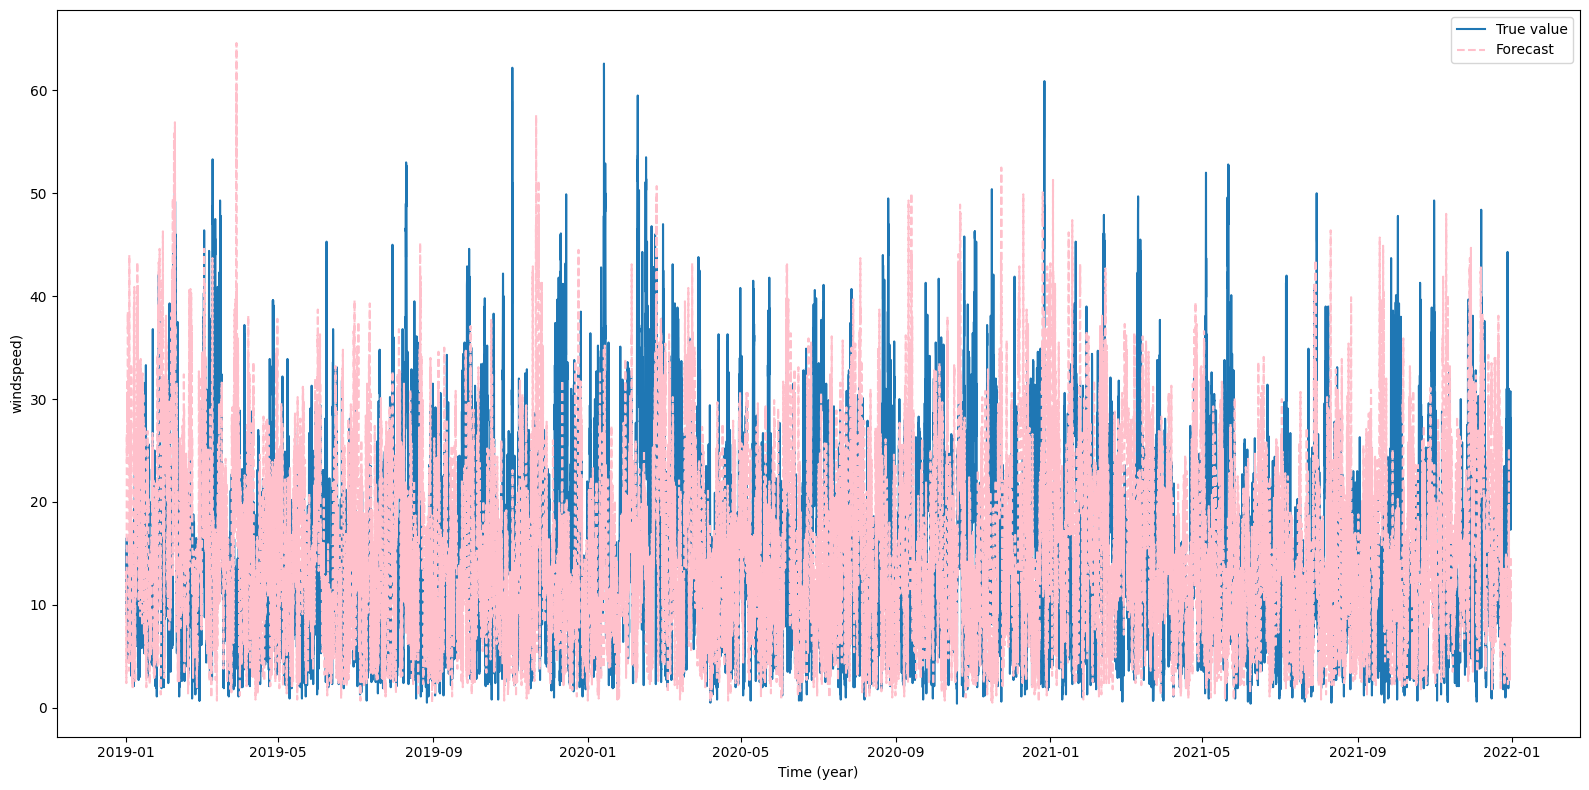

In [25]:
# hear i applied it on the wind column i just want to take a look at the windspeed  and see how it looks like
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import r2_score
# taking the last four year and implement tge function to calculate the mae
validation_filled['baseline_last_period'] = train_filled.loc['2016-01-01':'2018-12-31 00:00:00']['windspeed'].values
measure_forecast_error(validation_filled['windspeed'], validation_filled['baseline_last_period'])
# ploting 
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(validation_filled.index, validation_filled['windspeed'], label='True value')
ax.plot(validation_filled.index, validation_filled['baseline_last_period'], '--', color='pink', label='Forecast')

ax.set_xlabel('Time (year)')
ax.set_ylabel('windspeed)')

plt.legend(loc='best')
plt.tight_layout()
plt.savefig('./baseline_periodicity.pdf', dpi=1000)

# Machine learining 

In [26]:
# taking the solarradiation column and make it my data set
sol_df = train_filled['solarradiation'].copy().to_frame()  
# We want to forecast 24 hours and i will create windows of the last day (so 24 hours)
forecast_horizon = 24  # next day
window_size =24  # use one day of data
for lag in range(window_size-1):
    sol_df['sol_lag%d' % (lag+1)] = sol_df['solarradiation'].shift(lag+1)
sol_df['y'] = sol_df['solarradiation'].shift(-forecast_horizon)  # our target
sol_df.head()

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2010-01-01 01:00:00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2010-01-01 02:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2010-01-01 03:00:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2010-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [27]:
# We have missing values in the first rows because of the lags. Let's drop those
sol_df.dropna(inplace=True)
sol_df

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-01 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.8,93.4,...,23.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.8,...,93.0,23.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,137.4,93.0,23.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,183.4,137.4,93.0,23.6,0.0,0.0,0.0,0.0,0.0,0.0
2010-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,179.8,183.4,137.4,93.0,23.6,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-29 20:00:00,0.0,0.0,0.0,0.0,11.0,37.0,80.0,83.0,55.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-29 21:00:00,0.0,0.0,0.0,0.0,0.0,11.0,37.0,80.0,83.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-29 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,11.0,37.0,80.0,83.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# doing the same to the validation 
sol_df_val = validation_filled['solarradiation'].copy().to_frame() 
forecast_horizon = 24  # next day
window_size =24  
for lag in range(window_size-1):
    sol_df_val['sol_lag%d' % (lag+1)] = sol_df_val['solarradiation'].shift(lag+1)
sol_df_val['y'] = sol_df_val['solarradiation'].shift(-forecast_horizon)  # our target
sol_df_val.head()

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
2019-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2019-01-01 01:00:00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2019-01-01 02:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2019-01-01 03:00:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2019-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [29]:
# We have missing values in the first rows because of the lags. Let's drop those
sol_df_val.dropna(inplace=True)
sol_df_val

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
2019-01-01 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,54.0,90.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,54.0,...,27.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,...,70.0,27.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,62.0,70.0,27.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,174.0,62.0,70.0,27.0,4.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-29 20:00:00,0.0,0.0,0.0,0.0,23.0,64.0,57.0,47.0,58.0,29.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-12-29 21:00:00,0.0,0.0,0.0,0.0,0.0,23.0,64.0,57.0,47.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-12-29 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,23.0,64.0,57.0,47.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-12-29 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,64.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# exculding the label from train and validation set
features = list(sol_df.columns)[:-1]
features = list(sol_df_val.columns)[:-1]

In [31]:
# using huber regressor on the va
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
model = HuberRegressor(max_iter=10000)
model.fit(sol_df[features], sol_df['y'])
sol_df_val['y_pred'] = model.predict(sol_df_val[features])
 
measure_forecast_error(sol_df_val['y'], sol_df_val['y_pred'])

MAE = 50.17 
MAPE = inf%
R2 = 0.71


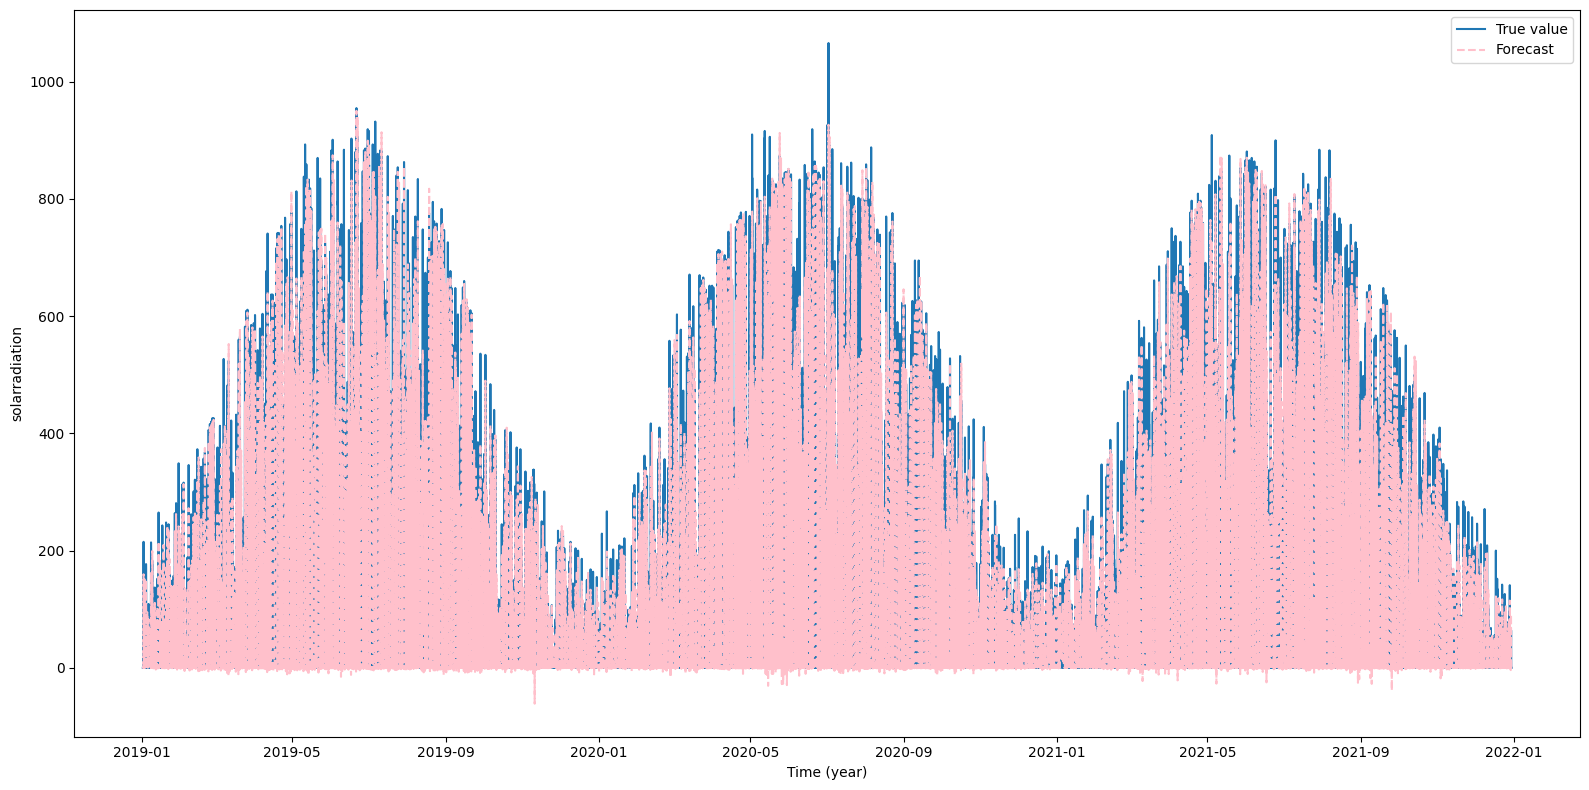

In [32]:
#plot the forcasting and the true value
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(sol_df_val.index, sol_df_val['solarradiation'], label='True value')
ax.plot(sol_df_val.index, sol_df_val['y_pred'], '--', color='pink', label='Forecast')
ax.set_xlabel('Time (year)')
ax.set_ylabel('solarradiation')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('./baseline_periodicity.pdf', dpi=1000)

after seeing that my mae of huber regressor is better than mae of baseline model i will use the test set with the huber regrssor and make my prediction 

In [33]:
# now doing the same to the test set 
sol_df_test = test_filled['solarradiation'].copy().to_frame()  
# We want to forecast one day so we will choose 24
forecast_horizon = 24  # next month
window_size =24  # use one day of data
for lag in range(window_size-1):
    sol_df_test['sol_lag%d' % (lag+1)] = sol_df_test['solarradiation'].shift(lag+1)
sol_df_test['y'] = sol_df_test['solarradiation'].shift(-forecast_horizon)  # our target
sol_df_test.head()

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
2022-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2022-01-01 01:00:00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2022-01-01 02:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2022-01-01 03:00:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2022-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [34]:
# We have missing values in the first rows because of the lags. Let's drop those
sol_df_test.dropna(inplace=True)
sol_df_test

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y
2022-01-01 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,84.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,...,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,...,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,63.0,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-05 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,11.0,35.0,47.0,56.0,105.0,35.0,7.0,0.0
2024-01-05 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,35.0,47.0,56.0,105.0,35.0,0.0
2024-01-05 09:00:00,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,35.0,47.0,56.0,105.0,23.0
2024-01-05 10:00:00,70.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,35.0,47.0,56.0,72.0


In [35]:
features = list(sol_df_test.columns)[:-1]

In [36]:
sol_df_test['y_pred'] = model.predict(sol_df_test[features])
measure_forecast_error(sol_df_test['y'], sol_df_test['y_pred'])

MAE = 52.72 
MAPE = inf%
R2 = 0.70


i will approximate my mae to 53 because the all calculation is maded of assumption so i choose to approximate the number for easier calcuations 

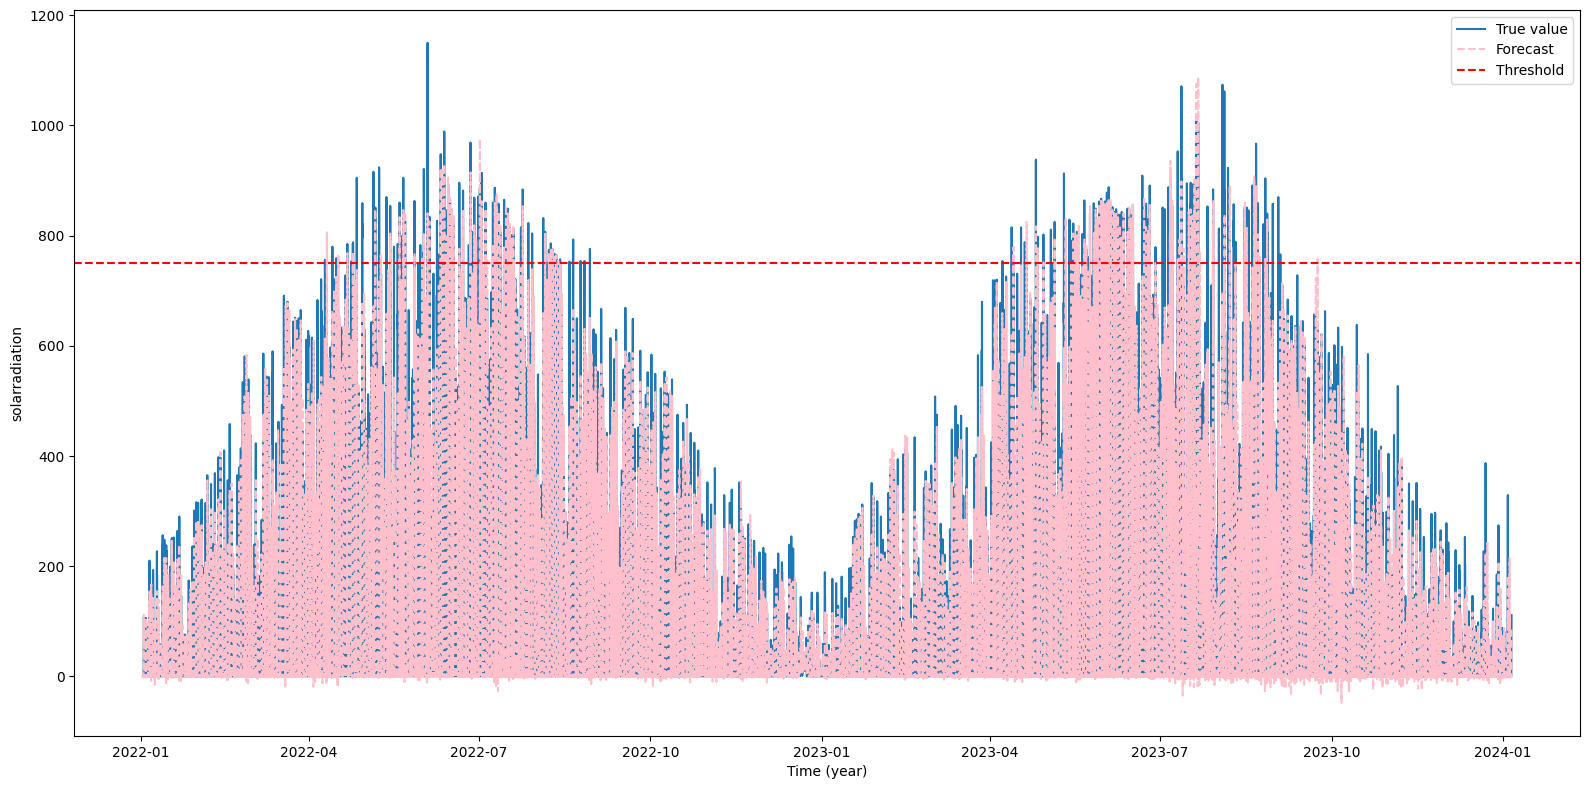

In [37]:
#ploting the result
import matplotlib.pyplot as plt
# Set your threshold value
threshold = 750  # Adjust the threshold value as needed
# Plot the true values and forecasted values on the test set 
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(sol_df_test.index, sol_df_test['solarradiation'], label='True value')
ax.plot(sol_df_test.index, sol_df_test['y_pred'], '--', color='pink', label='Forecast')

# Add a horizontal line for the threshold
ax.axhline(y=threshold, color='red', linestyle='--', label='Threshold')

ax.set_xlabel('Time (year)')
ax.set_ylabel('solarradiation')

plt.legend(loc='best')
plt.tight_layout()
plt.show()


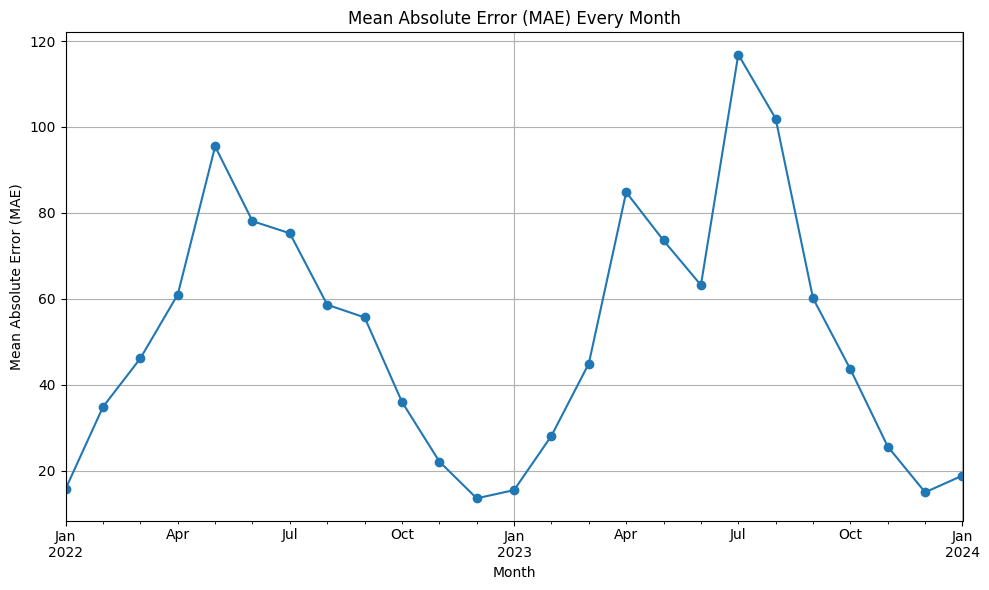

In [38]:
# ploting the mae on the test set for every month 
import matplotlib.pyplot as plt
import pandas as pd
# Calculate the MAE for every month
monthly_mae = sol_df_test.resample('ME').apply(lambda x: (x['y'] - x['y_pred']).abs().mean())

# Plot the monthly MAE
plt.figure(figsize=(10, 6))
monthly_mae.plot(marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Mean Absolute Error (MAE) Every Month')
plt.grid(True)
plt.tight_layout()
plt.show()

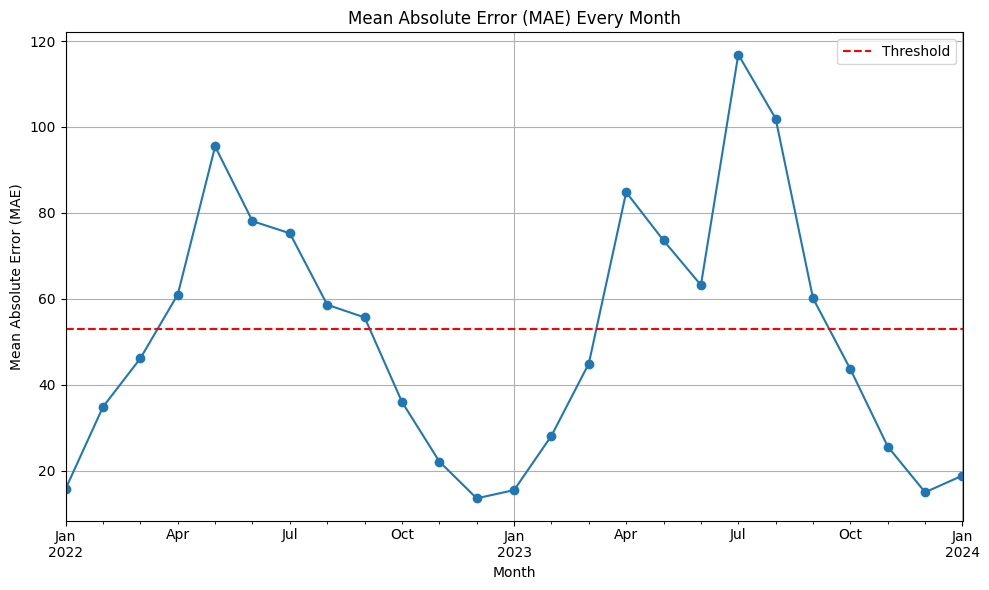

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot the monthly MAE
plt.figure(figsize=(10, 6))
monthly_mae.plot(marker='o', linestyle='-')

# Set the threshold value let say that the accaptable error is 53 which is my possible error 
threshold = 53  # Adjust the threshold value as needed

# Plot the threshold line
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

plt.xlabel('Month')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Mean Absolute Error (MAE) Every Month')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# We have missing values in the first rows because of the lags. Let's drop those
sol_df_test.dropna(inplace=True)
sol_df_test

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23,y,y_pred
2022-01-01 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,84.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.687310
2022-01-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.783351
2022-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,...,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.704810
2022-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.781484
2022-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.809242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-05 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,11.0,35.0,47.0,56.0,105.0,35.0,7.0,0.0,0.677421
2024-01-05 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,11.0,35.0,47.0,56.0,105.0,35.0,0.0,-1.880718
2024-01-05 09:00:00,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,35.0,47.0,56.0,105.0,23.0,59.996664
2024-01-05 10:00:00,70.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,35.0,47.0,56.0,72.0,61.067707


In [41]:
sol_df_test = test_filled['solarradiation'].copy().to_frame() 
forecast_horizon = 24  
window_size =24 
for lag in range(window_size-1):
    sol_df_test['sol_lag%d' % (lag+1)] = sol_df_test['solarradiation'].shift(lag+1)

sol_df_test.head()

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag14,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23
2022-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 03:00:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# We have missing values in the first rows because of the lags. Let's drop those
sol_df_test.dropna(inplace=True)
sol_df_test

,solarradiation,sol_lag1,sol_lag2,sol_lag3,sol_lag4,sol_lag5,sol_lag6,sol_lag7,sol_lag8,sol_lag9,...,sol_lag14,sol_lag15,sol_lag16,sol_lag17,sol_lag18,sol_lag19,sol_lag20,sol_lag21,sol_lag22,sol_lag23
2022-01-01 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,84.0,...,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,30.0,...,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,...,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,63.0,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,116.0,63.0,135.0,63.0,22.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-06 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7.0,21.0,102.0,207.0,134.0,111.0,70.0,33.0,0.0
2024-01-06 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,7.0,21.0,102.0,207.0,134.0,111.0,70.0,33.0
2024-01-06 09:00:00,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,7.0,21.0,102.0,207.0,134.0,111.0,70.0
2024-01-06 10:00:00,72.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.0,21.0,102.0,207.0,134.0,111.0


In [43]:
#the values of the day that we want to predict so this is the predicted values of the solarrdation in the 24 hours in advance
sol_df_test['y_pred'] = model.predict(sol_df_test)
sol_df_test['y_pred'].tail(24)

2024-01-05 12:00:00    101.857121
2024-01-05 13:00:00    130.037375
2024-01-05 14:00:00     90.389584
2024-01-05 15:00:00     26.791232
2024-01-05 16:00:00      5.519593
2024-01-05 17:00:00      1.685204
2024-01-05 18:00:00      0.323143
2024-01-05 19:00:00      0.441917
2024-01-05 20:00:00      0.512491
2024-01-05 21:00:00      0.541898
2024-01-05 22:00:00      0.728350
2024-01-05 23:00:00      0.659102
2024-01-06 00:00:00      0.734735
2024-01-06 01:00:00      0.748245
2024-01-06 02:00:00      0.796725
2024-01-06 03:00:00      0.706753
2024-01-06 04:00:00      0.763043
2024-01-06 05:00:00      0.707782
2024-01-06 06:00:00      1.621212
2024-01-06 07:00:00     -4.230569
2024-01-06 08:00:00      6.576826
2024-01-06 09:00:00     27.545758
2024-01-06 10:00:00     75.525589
2024-01-06 11:00:00    128.129176
Freq: h, Name: y_pred, dtype: float64

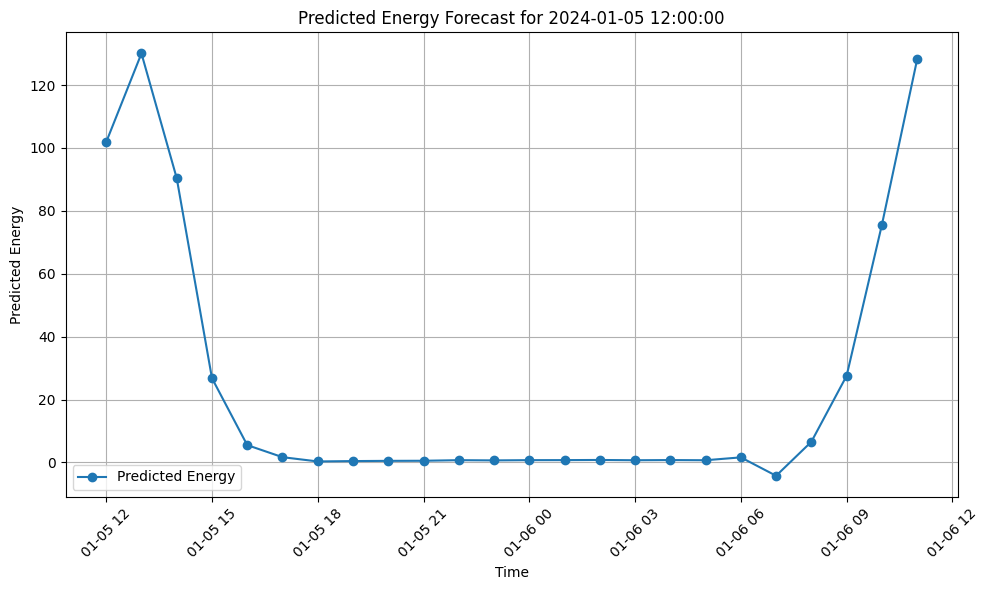

In [44]:
# ploting this value
import matplotlib.pyplot as plt
# Define the start and end dates for the desired date range
start_date = '2024-01-05 12:00:00'
end_date = '2024-01-06 11:00:00'
# Filter the DataFrame to include only the data for the specified date range
filtered_data = sol_df_test.loc[start_date:end_date]
# Plotting the y_pred column with values for every hour for the specified date range
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['y_pred'], label='Predicted Energy', marker='o')
# Adding labels and title
plt.xlabel('Time')
plt.ylabel('Predicted Energy')
plt.title('Predicted Energy Forecast for {}'.format(start_date))
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
# Display the plot
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

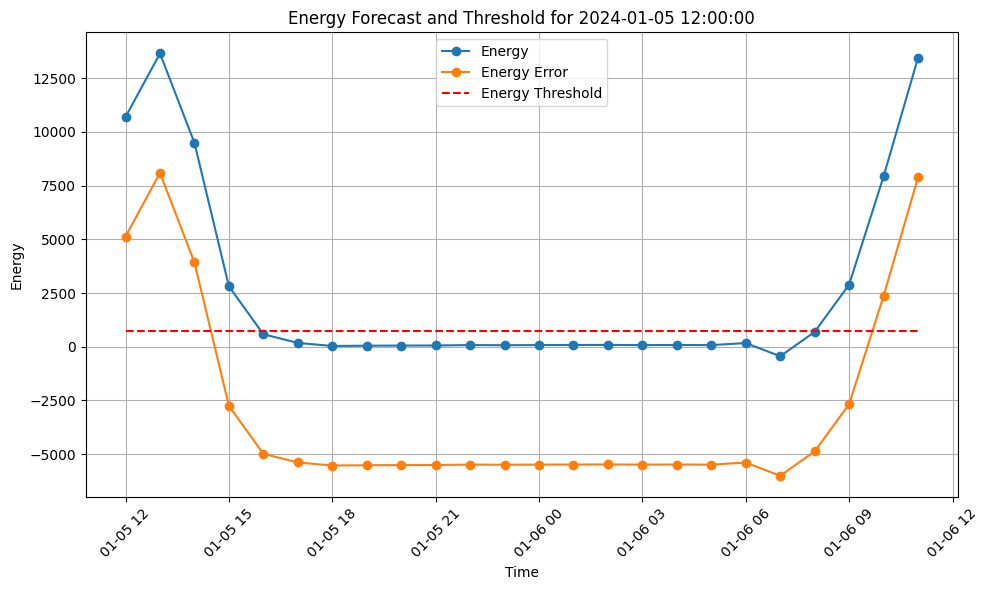

In [45]:
# calculating the surplius in energy for 24 in advance and ploting it with the surplus energy taking in consideration false positive
sol_df_test['energy'] = (1.5 * 0.5 * sol_df_test['y_pred'] * 0.7) * 200
sol_df_test['energy-error'] = (1.5 * 0.5 * (sol_df_test['y_pred']-53) * 0.7) * 200
sol_df_test['energy-th'] = 750
import matplotlib.pyplot as plt

# Define the start and end dates for the desired date range
start_date = '2024-01-05 12:00:00'
end_date = '2024-01-06 11:00:00'

# Filter the DataFrame to include only the data for the specified date range
filtered_data = sol_df_test.loc[start_date:end_date]

# Plotting the 'energy' and 'energy_th' columns for the specified date range
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['energy'], label='Energy', marker='o')
plt.plot(filtered_data.index, filtered_data['energy-error'], label='Energy Error', marker='o')
plt.plot(filtered_data.index, filtered_data['energy-th'], label='Energy Threshold', color='r', linestyle='--')



# Adding labels and title
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy Forecast and Threshold for {}'.format(start_date))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


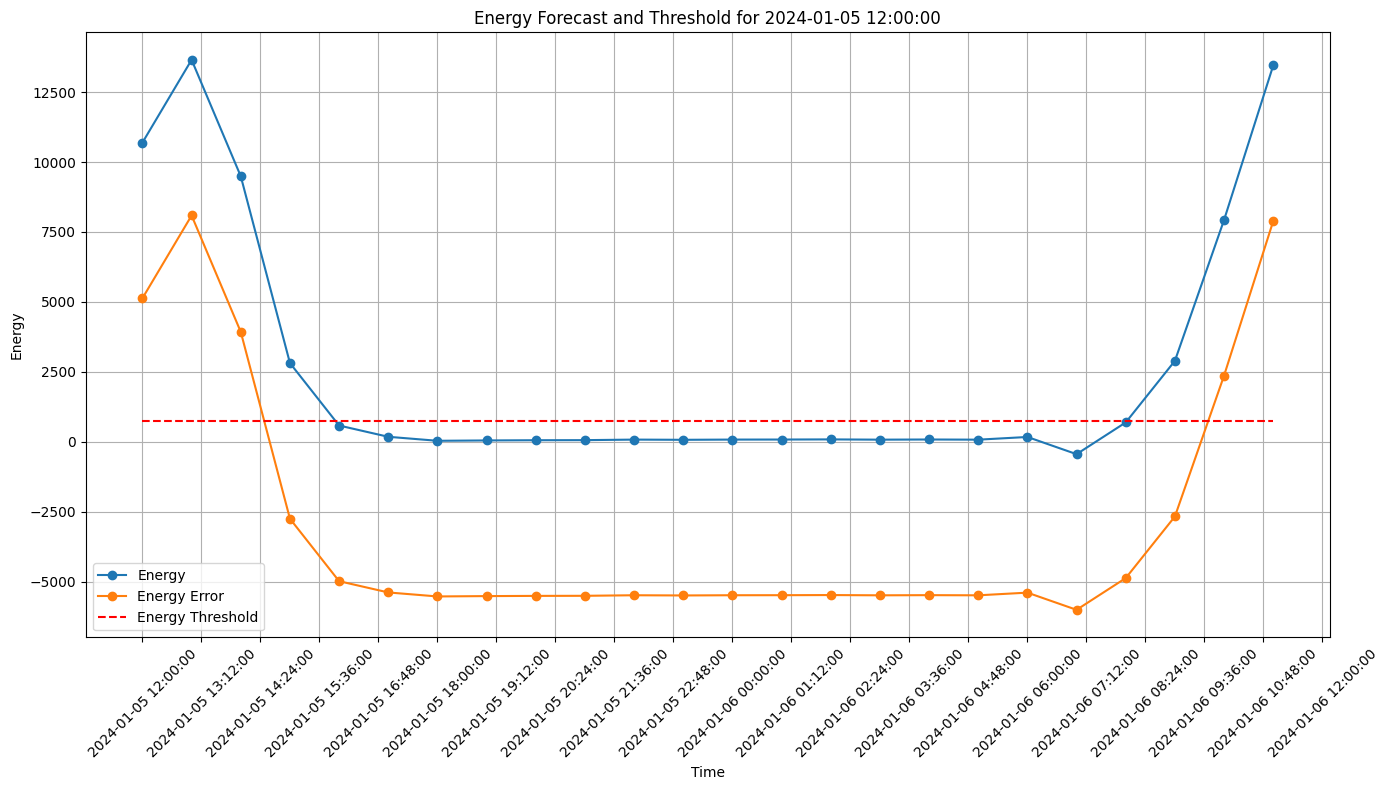

In [46]:
# for seeing the hours in more convienent way 
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Define the start and end dates for the desired date range
start_date = '2024-01-05 12:00:00'
end_date = '2024-01-06 11:00:00'

# Filter the DataFrame to include only the data for the specified date range
filtered_data = sol_df_test.loc[start_date:end_date]

# Plotting the 'energy' and 'energy_th' columns for the specified date range
plt.figure(figsize=(14, 8))  # Adjust figure size as needed
plt.plot(filtered_data.index, filtered_data['energy'], label='Energy', marker='o')
plt.plot(filtered_data.index, filtered_data['energy-error'], label='Energy Error', marker='o')
plt.plot(filtered_data.index, filtered_data['energy-th'], label='Energy Threshold', color='r', linestyle='--')

# Adding labels and title
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy Forecast and Threshold for {}'.format(start_date))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Customize x-axis ticks to include hour
date_form = DateFormatter("%Y-%m-%d %H:%M:%S")
plt.gca().xaxis.set_major_formatter(date_form)

# Display every hour
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(24))

# Display the plot
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

this plot shows us that we can decide to offer free energy from 12 until 15 pm and agin from 9 to the 11 because it will be surplus energy. However, if we want to take false positive in our account and we want to reduce the risk of offering free energy when there is no surplus in energy we will subtract the error of predicted solarradation from the predicted values then calculated the surplus energy. what happened is that we will advice the company to offer energy from 12 to 14 and on 11 so only 3 hours. this will reduce the risk of losing money for the company